<a href="https://colab.research.google.com/github/SirisPudasai/Deep-Learning/blob/main/TransferLearning_VGG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("antobenedetti/animals")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'animals' dataset.
Path to dataset files: /kaggle/input/animals


In [39]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16

In [40]:
conv_base=VGG16(
    include_top=False,
    weights="imagenet",
    input_shape=(150,150,3),
)


In [41]:
conv_base.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 9, 9, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model=Sequential()
model.add(conv_base)
model.add(Flatten())
model.add(Dense(512,activation='relu'))
model.add(Dense(5,activation='softmax'))

In [43]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,912,069 (72.14 MB)

 Trainable params: 18,912,069 (72.14 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
conv_base.trainable =False

In [45]:
#Generator
train_ds=keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/animals/animals/train',
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(150, 150),
    shuffle=True,

)
validation_ds=keras.utils.image_dataset_from_directory(
    directory='/kaggle/input/animals/animals/val',
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(150, 150),
    shuffle=True,

)


Found 13474 files belonging to 5 classes.
Found 1497 files belonging to 5 classes.


In [46]:
#Normalize
def process(image,label):
  image = tf.cast(image/255., tf.float32)
  return image,label

train_ds=train_ds.map(process)
validation_ds=validation_ds.map(process)

In [47]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [48]:
history=model.fit(train_ds,epochs=10,validation_data=validation_ds)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 54s 121ms/step - accuracy: 0.8557 - loss: 0.3936 - val_accuracy: 0.8911 - val_loss: 0.2844
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 52s 122ms/step - accuracy: 0.9204 - loss: 0.2086 - val_accuracy: 0.9071 - val_loss: 0.2422
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 51s 121ms/step - accuracy: 0.9417 - loss: 0.1511 - val_accuracy: 0.9185 - val_loss: 0.2158
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 52s 122ms/step - accuracy: 0.9581 - loss: 0.1121 - val_accuracy: 0.9145 - val_loss: 0.2408
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 52s 122ms/step - accuracy: 0.9648 - loss: 0.0952 - val_accuracy: 0.9085 - val_loss: 0.2835
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 51s 121ms/step - accuracy: 0.9789 - loss: 0.0597 - val_accuracy: 0.8898 - val_loss: 0.3649
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 51s 121ms/step - accuracy: 0.9751 - loss: 0.0703 - val_accuracy: 0.8884 - val_loss: 0.4044
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 52s 122ms/step - accuracy: 0.9793 - loss: 0

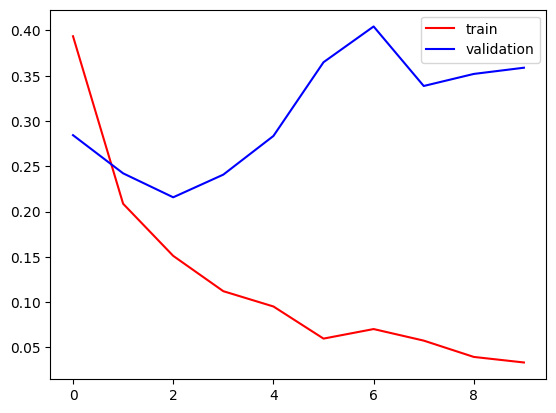

In [49]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

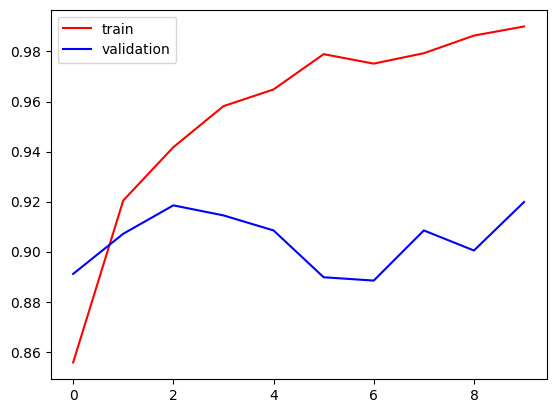

In [51]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

In [52]:
import cv2

In [60]:
test_img=cv2.imread('/lions.jpg')

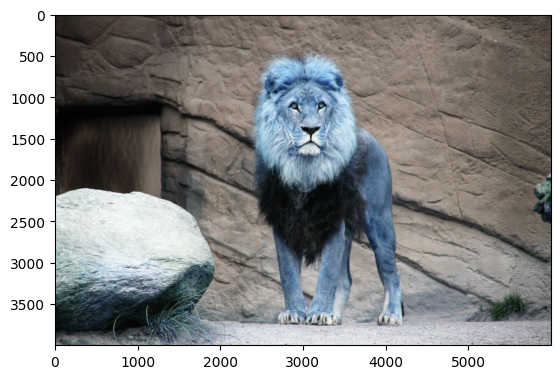

In [61]:
plt.imshow(test_img)

In [62]:
test_img=cv2.resize(test_img,(150,150))

In [63]:
test_input=test_img.reshape((1,150,150,3))

In [64]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


array([[0., 0., 0., 0., 1.]], dtype=float32)